In [4]:
import matplotlib.pyplot as plt
import numpy as np
import h5py
import copy
import pandas as pd
from scipy import optimize
from matplotlib import pyplot as plt
import pickle
from itertools import cycle
import matplotlib.colors as mcolors
import astropy.units as u
import astropy.constants as const

from photochem.utils import stars
import PICASO_Climate_grid_121625 as picaso_grid
import Photochem_grid_121625 as photochem_grid
import Reflected_Spectra_grid_13026 as Reflected_Spectra
from picaso.photochem import EquilibriumChemistry
import GraphsKey

import os
from pathlib import Path

current_directory = Path.cwd()
references_directory_path = "Installation&Setup_Instructions/picasofiles/reference"
PYSYN_directory_path = "Installation&Setup_Instructions/picasofiles/grp/redcat/trds"
print(os.path.join(current_directory, references_directory_path))
print(os.path.join(current_directory, PYSYN_directory_path))

os.environ['picaso_refdata']= os.path.join(current_directory, references_directory_path)
os.environ['PYSYN_CDBS']= os.path.join(current_directory, PYSYN_directory_path)


import picaso.justdoit as jdi
import picaso.justplotit as jpi

AttributeError: module 'numpy.core.multiarray' has no attribute 'flexible'

In [3]:
import numpy as np
print(np.__version__)

1.26.4


In [ ]:
opacity_path = os.path.join(
    current_directory,
    "Installation&Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000.db"
)
print(opacity_path)
OPACITY_EARTH = jdi.opannection(filename_db=opacity_path, wave_range=[0.3, 2.5])

In [ ]:
def find_pbot(sol=None, solaer=None, tol=0.9):

    """
    Parameters:
    pressures: ndarray
        Pressure at each atmospheric layer in dynes/cm^2
    H2Oaer: ndarray
        Mixing ratio of H2O aerosols.
    tol: float, optional
        The threshold value for which we define the beginning of the cloud,
        by default 1e-4.

    Returns:
    P_bottom: float
        The cloud bottom pressure in dynes/cm^2

    """

    pressure = sol['pressure']
    H2Oaer = solaer['H2Oaer']

    # There is no water cloud in the model, so we return None
    # For the cloud bottom of pressure

    if np.max(H2Oaer) < 1e-20:
        return None

    # Normalize so that max value is 1
    H2Oaer_normalized = H2Oaer/np.max(H2Oaer)

    # loop from bottom to top of atmosphere, cloud bottom pressure
    # defined as the index level where the normalized cloud mixing ratio
    # exeeds tol .

    ind = None

    for i, val in enumerate(H2Oaer_normalized):
        if val > tol:
            ind = i
            break

    if ind is None:
        raise Exception('A problem happened when trying to find the bottom of the cloud.')

    # Bottom of the cloud
    pbot = pressure[ind]

    return pbot

In [ ]:
def _add_cloud_deck(case, ptop_bar, pbot_bar, w0=0.99, g0=0.85, opd=10):
    """Add a grey cloud deck between ptop_bar and pbot_bar (pressures in bars)."""
    logdp = np.log10(pbot_bar) - np.log10(ptop_bar)
    case.clouds(w0=[w0], g0=[g0], p=[np.log10(pbot_bar)], dp=[logdp], opd=[opd])

In [ ]:
earth_spectrum(
    df_mol_earth=None,
    phase=0.0,
    atmosphere_kwargs=None,
    cloud_frac=0.5,
    p_surface_bar=1.0,
    nlevel=90,
    cloud_ptop_bar=0.6,
    cloud_pbot_bar=0.7,
    no_rayleigh=False,
    outputfile=None,
    exclude_all_gas=False,
):
    """
    Calculates Earth reflected spectrum around the Sun.

    Parameters:
    opacity_path: str
        Path to the opacity file.
    df_mol_earth: dict or None
        Molecular mixing ratios. If None, defaults to modern Earth composition.
    phase: float
        Phase angle in radians.
    atmosphere_kwargs: dict or None
        Optional. Keys: 'exclude_mol' — list of molecule names to zero out.
        All listed species are zeroed out (loops over the full list).
    cloud_frac: float
        Cloud fraction (0–1) for weighted average of cloudy/cloud-free spectra.
    p_surface_bar: float
        Surface pressure in bars. Default 1.0 matches modern Earth.
        Increase to simulate a deeper/thicker atmosphere (e.g. gas planet analogue).
    nlevel: int
        Number of atmospheric pressure levels.
    cloud_ptop_bar: float
        Cloud top pressure in bars.
    cloud_pbot_bar: float
        Cloud bottom pressure in bars.

    Returns:
    wno, fpfs, albedo, df_cld, df_cldfree
    """
    if atmosphere_kwargs is None:
        atmosphere_kwargs = {}

    earth = jdi.inputs()
    earth.phase_angle(phase, num_tangle=8, num_gangle=8)
    earth.gravity(radius=1, radius_unit=jdi.u.Unit('R_earth'),
                  mass=1, mass_unit=jdi.u.Unit('M_earth'))
    earth.approx(raman="none")

    earth.star(opannection=OPACITY_EARTH, temp=5778, logg=4.4, semi_major=1,
               metal=0.0, semi_major_unit=u.Unit('au'))

    P = np.logspace(-6, np.log10(p_surface_bar), nlevel)
    df_atmo = earth.TP_line_earth(P, nlevel=nlevel)
    df_pt_earth = pd.DataFrame({
        'pressure': df_atmo['pressure'].values,
        'temperature': df_atmo['temperature'].values,
    })

    if df_mol_earth is None:
        df_mol_earth = {
            "N2": 0.79, "O2": 0.21, "O3": 7e-7,
            "H2O": 3e-3, "CO2": 300e-6, "CH4": 1.7e-6,
        }

    df_mol_grid = pd.DataFrame({key: P * 0 + val for key, val in df_mol_earth.items()})
    df_atmo_earth = df_pt_earth.join(df_mol_grid, how='inner')

    if 'exclude_mol' in atmosphere_kwargs:
        for sp in atmosphere_kwargs['exclude_mol']:
            if sp in df_atmo_earth:
                df_atmo_earth[sp] *= 0

    if exclude_all_gas:
        _excl = {sp: ['line', 'continuum'] for sp in df_atmo_earth.columns if sp not in ['pressure', 'temperature']}
        earth.atmosphere(df=df_atmo_earth, exclude_mol=_excl)
    elif no_rayleigh:
        _excl = {sp: ['rayleigh'] for sp in df_atmo_earth.columns if sp not in ['pressure', 'temperature']}
        earth.atmosphere(df=df_atmo_earth, exclude_mol=_excl)
    else:
        earth.atmosphere(df=df_atmo_earth)
    earth.surface_reflect(0.1, OPACITY_EARTH.wno)

    df_cldfree = earth.spectrum(OPACITY_EARTH, calculation='reflected', full_output=True)

    _add_cloud_deck(earth, cloud_ptop_bar, cloud_pbot_bar)
    df_cld = earth.spectrum(OPACITY_EARTH, full_output=True)

    wno = df_cldfree['wavenumber']
    fpfs_cf = df_cldfree['fpfs_reflected']
    albedo_cf = df_cldfree['albedo']
    fpfs_c = df_cld['fpfs_reflected']
    albedo_c = df_cld['albedo']

    _, albedo = jdi.mean_regrid(wno, (1 - cloud_frac) * albedo_cf + cloud_frac * albedo_c, R=150)
    wno, fpfs = jdi.mean_regrid(wno, (1 - cloud_frac) * fpfs_cf + cloud_frac * fpfs_c, R=150)

    if outputfile is not None:
        _suffix = f'_phase{phase:.4f}_cld{cloud_frac}_psurf{p_surface_bar}'
        if exclude_all_gas:
            _suffix += '_nogas'
        elif 'exclude_mol' in atmosphere_kwargs:
            _suffix += '_no' + ''.join(atmosphere_kwargs['exclude_mol'])
        if no_rayleigh:
            _suffix += '_noray'
        _out = Path(outputfile)
        _save_path = _out.parent / f'EarthSpectrum_{_out.name}{_suffix}.pkl'
        _save_path.parent.mkdir(parents=True, exist_ok=True)
        earth_outputs = {
            'wno': wno,
            'fpfs': fpfs,
            'albedo': albedo,
            'df_cld': df_cld,
            'df_cldfree': df_cldfree,
        }
        with open(_save_path, 'wb') as f:
            pickle.dump(earth_outputs, f)
        print(f'Saved {_save_path}')

    return wno, fpfs, albedo, df_cld, df_cldfree

In [ ]:
from cycler import cycler

def plot_reflected_spectrum(wno=None, alb=None, inputs=None, legend_label=None, ax1=None, fill_curves=None):
    """
    wno = list of wavenumbers to plot (can be [[],[]]...)
    alb = list of albedos associated with wavenumbers (can be [[],[]...])
    inputs = list of inputs associated with the wavenumbers and albedos (can be [[],[],...]); |
        note inputs should be ordered like radius, metallicity, internal temperature, 
        semi-major axis, c/o ratio, and kzz mixing coefficient.
    legend_label = list of strings describing what dataset you are pulling from
    fill_curves = a float; fills the last fill_curve value of curves
    """
        
    # Define a list of colors or use a color cycle
    colors = ['green', 'red', 'orange']

    if ax1 is None:
        fig, ax1 = plt.subplots(1,1,figsize=[10,4])

    for index in range(len(wno)):

        # Fill last two curves
        if fill_curves is not None:
            if index >= len(wno) - fill_curves:
                line, = ax1.plot(1e4/wno[index], alb[index], linestyle='--', lw=0.5, label=legend_label)
                ax1.fill_between(1e4/wno[index], alb[index], color=line.get_color(), alpha=0.15)
            else:
                ax1.plot(1e4/wno[index], alb[index], linestyle='-', lw=2, label=legend_label)

        else:
            ax1.plot(1e4/wno[index], alb[index], linestyle='-', lw=2, label=legend_label)
        
    ax1.set_prop_cycle(cycler(color=['red', 'green', 'blue', 'orange']))

    ax1.set_xlim(0, 2.5)
    #ax1.set_ylim(0, 0.35)
    ax1.set_ylabel('Albedo')
    ax1.set_xlabel('Wavelength (microns)')

    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    if ax1 is None:
        plt.tight_layout()
        
        plt.show()

In [ ]:
df_mol_modern_earth = {
        "N2":0.79,
        "O2":0.21,
        "O3":7e-7,
        "H2O":3e-3,
        "CO2":300e-6,
        "CH4":1.7e-6
    }

In [ ]:
wno_modernearth_noray, fpfs_modernearth_noray, albedo_modernearth_noray, df_cld_modernearth_noray, df_cldfree_modernearth_noray = earth_spectrum(
    df_mol_earth=df_mol_modern_earth,
    phase=0.0,
    atmosphere_kwargs=None,
    cloud_frac=0.5,
    p_surface_bar=1.0,
    nlevel=90,
    cloud_ptop_bar=0.6,
    cloud_pbot_bar=0.7,
    no_rayleigh=True,
    outputfile=None,
    exclude_all_gas=False,
)

In [38]:
print(albedo_modernearth_noray)

[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan na

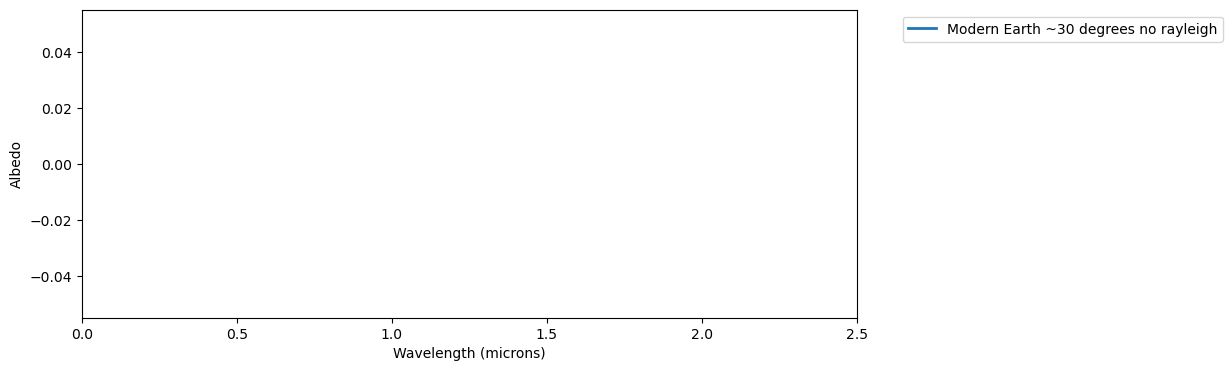

In [37]:
plot_reflected_spectrum(wno=[wno_modernearth_noray], alb=[albedo_modernearth_noray], inputs=[None], legend_label=['Modern Earth ~30 degrees no rayleigh'], ax1=None, fill_curves=None)